# Dueling Contextual Bandit for Fair Model Initialization

This notebook learns fair initialization scores for all 20 LLM models from pairwise comparison data.

Instead of simple aggregation (which biases by matchup frequency), dueling bandits learn context-aware quality weights that account for opponent strength.

**Dataset**: df_bandit.json (25,322 records, all 20 models)

## 1. Import Required Libraries

In [95]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import os

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully")

All libraries imported successfully


## 2. Load and Explore the Dataset

In [96]:
# Load df_bandit.json dataset (using new version with all 20 models)
print("Loading df_bandit.json...")
df = pd.read_json('data/df_bandit.json', lines=True)

print(f"Dataset loaded: {len(df)} records")
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Loading df_bandit.json...
Dataset loaded: 25322 records

Dataset Shape: (25322, 14)

Columns (14):
['question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'turn', 'language', 'tstamp', 'toxic_either', 'prompt_text', 'length', 'difficulty']


In [97]:
# Display first few rows
print("First 3 rows:")
df.head(3)

First 3 rows:


,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,turn,language,tstamp,toxic_either,prompt_text,length,difficulty
0,58210e39b3fd4441a2bd4a518bb44c2d,chatglm-6b,koala-13b,model_b,arena_user_973,[{'content': 'What is the difference between O...,[{'content': 'What is the difference between O...,1,English,1.682352e+09,False,What is the difference between OpenCL and CUDA?,47,0.183708
1,2564acd09e3942fd97657d05282d4389,oasst-pythia-12b,alpaca-13b,tie,arena_user_973,[{'content': 'Why did my parent not invite me ...,[{'content': 'Why did my parent not invite me ...,1,English,1.682352e+09,False,Why did my parent not invite me to their wedding?,49,0.124306
2,90bfd142157948aba01931726c888e7f,koala-13b,oasst-pythia-12b,model_b,arena_user_973,"[{'content': 'Fuji vs. Nikon, which is better?...","[{'content': 'Fuji vs. Nikon, which is better?...",1,English,1.682352e+09,False,"Fuji vs. Nikon, which is better?",32,0.178102


In [98]:
# Data types and missing values
print("\n--- Data Quality ---")
print(f"Missing values:\n{df.isnull().sum().sum()} total missing values")

print(f"\nData types:")
print(df.dtypes)


--- Data Quality ---
Missing values:
0 total missing values

Data types:
question_id           str
model_a               str
model_b               str
winner                str
judge                 str
conversation_a     object
conversation_b     object
turn                int64
language              str
tstamp            float64
toxic_either         bool
prompt_text           str
length              int64
difficulty        float64
dtype: object


In [99]:
# Explore unique models and features
all_models = sorted(list(set(df['model_a'].unique()) | set(df['model_b'].unique())))
print(f"\n--- Models ---")
print(f"Total unique models: {len(all_models)}\n")
for i, model in enumerate(all_models, 1):
    print(f"{i:2d}. {model}")


--- Models ---
Total unique models: 20

 1. RWKV-4-Raven-14B
 2. alpaca-13b
 3. chatglm-6b
 4. claude-instant-v1
 5. claude-v1
 6. dolly-v2-12b
 7. fastchat-t5-3b
 8. gpt-3.5-turbo
 9. gpt-4
10. gpt4all-13b-snoozy
11. guanaco-33b
12. koala-13b
13. llama-13b
14. mpt-7b-chat
15. oasst-pythia-12b
16. palm-2
17. stablelm-tuned-alpha-7b
18. vicuna-13b
19. vicuna-7b
20. wizardlm-13b


In [100]:
# Summary statistics for continuous features
print("\n--- Continuous Features ---")
print(f"\nDifficulty (continuous [0, 1]):")
print(f"  Mean: {df['difficulty'].mean():.4f}")
print(f"  Std: {df['difficulty'].std():.4f}")
print(f"  Min: {df['difficulty'].min():.4f}")
print(f"  Max: {df['difficulty'].max():.4f}")

print(f"\nPrompt Length (character count):")
print(f"  Mean: {df['length'].mean():.1f}")
print(f"  Std: {df['length'].std():.1f}")
print(f"  Min: {df['length'].min():.1f}")
print(f"  Max: {df['length'].max():.1f}")


--- Continuous Features ---

Difficulty (continuous [0, 1]):
  Mean: 0.2025
  Std: 0.1240
  Min: 0.0200
  Max: 0.8800

Prompt Length (character count):
  Mean: 197.1
  Std: 369.9
  Min: 16.0
  Max: 2560.0


In [101]:
# Normalize continuous features before splitting
print("Normalizing continuous features to [0, 1]...\n")

# Normalize difficulty (already [0, 1])
df['difficulty_norm'] = df['difficulty'].astype(float)

# Normalize length to [0, 1] based on min-max scaling
min_length = df['length'].min()
max_length = df['length'].max()
df['length_norm'] = (df['length'] - min_length) / (max_length - min_length)

print(f"Difficulty (continuous [0, 1]):")
print(f"  Range: [{df['difficulty_norm'].min():.4f}, {df['difficulty_norm'].max():.4f}]")
print(f"  Mean: {df['difficulty_norm'].mean():.4f}")

print(f"\nLength (normalized [0, 1]):")
print(f"  Range: [{df['length_norm'].min():.4f}, {df['length_norm'].max():.4f}]")
print(f"  Mean: {df['length_norm'].mean():.4f}")

# Simple random 50/50 split
np.random.seed(42)
split_mask = np.random.rand(len(df)) < 0.5

df_phase1 = df[split_mask].reset_index(drop=True)
df_phase2 = df[~split_mask].reset_index(drop=True)

print("\n\nData Split: Phase 1 (Training) vs Phase 2 (Evaluation)")
print("=" * 70)
print(f"Total dataset:       {len(df):,} pairs")
print(f"Phase 1 (training):  {len(df_phase1):,} pairs ({len(df_phase1)/len(df):.1%})")
print(f"Phase 2 (eval):      {len(df_phase2):,} pairs ({len(df_phase2)/len(df):.1%})")

Normalizing continuous features to [0, 1]...

Difficulty (continuous [0, 1]):
  Range: [0.0200, 0.8800]
  Mean: 0.2025

Length (normalized [0, 1]):
  Range: [0.0000, 1.0000]
  Mean: 0.0712


Data Split: Phase 1 (Training) vs Phase 2 (Evaluation)
Total dataset:       25,322 pairs
Phase 1 (training):  12,596 pairs (49.7%)
Phase 2 (eval):      12,726 pairs (50.3%)


In [102]:
# Verify split quality: check model distribution across phases
print("\nSplit Quality Check: Model Appearance Distribution")
print("=" * 70)

model_counts_phase1 = defaultdict(int)
model_counts_phase2 = defaultdict(int)

for idx, row in df_phase1.iterrows():
    model_counts_phase1[row['model_a']] += 1
    model_counts_phase1[row['model_b']] += 1

for idx, row in df_phase2.iterrows():
    model_counts_phase2[row['model_a']] += 1
    model_counts_phase2[row['model_b']] += 1

print(f"\n{'Model':<35} {'Phase 1':<15} {'Phase 2':<15} {'Ratio':<10}")
print("-" * 75)

for model in sorted(all_models):
    count1 = model_counts_phase1[model]
    count2 = model_counts_phase2[model]
    total = count1 + count2
    ratio = count1 / count2 if count2 > 0 else count1
    print(f"{model:<35} {count1:<15} {count2:<15} {ratio:<10.2f}")



Split Quality Check: Model Appearance Distribution

Model                               Phase 1         Phase 2         Ratio     
---------------------------------------------------------------------------
RWKV-4-Raven-14B                    1405            1405            1.00      
alpaca-13b                          1705            1653            1.03      
chatglm-6b                          1348            1340            1.01      
claude-instant-v1                   973             1038            0.94      
claude-v1                           1508            1566            0.96      
dolly-v2-12b                        1053            1046            1.01      
fastchat-t5-3b                      1242            1234            1.01      
gpt-3.5-turbo                       1784            1822            0.98      
gpt-4                               1630            1652            0.99      
gpt4all-13b-snoozy                  365             390             0.94      
gu

In [103]:
output_path_phase2 = 'data/df_phase2_evaluation.json'

try:
    df_phase2.to_json(output_path_phase2, orient='records', indent=2)
    
    # Validate the file by reloading it
    with open(output_path_phase2, 'r') as f:
        test_data = json.load(f)
    
    print(f"  File: {output_path_phase2}")
    print(f"  Records: {len(test_data):,} pairs")

    
except Exception as e:
    print(f"ERROR saving Phase 2 data: {e}")
    import traceback
    traceback.print_exc()


  File: data/df_phase2_evaluation.json
  Records: 12,726 pairs


## 3. Define Dueling Contextual Bandit Class (Cost-Aware)

In [104]:
# Real API pricing (2023) — source: public pricing pages at time of Arena data
# Prices in USD per 1K tokens (input). Will be normalized to [0, 1]
RAW_COST_PER_1K = {
    'gpt-4':           0.03,
    'gpt-3.5-turbo':   0.002,
    'claude-v1':       0.011,
    'claude-instant-v1': 0.00163,
    'palm-2':          0.0005,
    'vicuna-13b':      0.0003,
    'vicuna-7b':       0.0002,
    'koala-13b':       0.0003,
    'oasst-pythia-12b': 0.0002,
    'alpaca-13b':      0.0003,
    'chatglm-6b':      0.0002,
    'stablelm-tuned-alpha-7b': 0.0002,
    'fastchat-t5-3b':  0.0001,
    'llama-13b':       0.0003,
    'dolly-v2-12b':    0.0002,
    'RWKV-4-Raven-14B': 0.0002,
    'mpt-7b-chat':     0.0002,
    'gpt4all-13b-snoozy': 0.0002,
    'guanaco-33b':     0.0003,
    'wizardlm-13b':    0.0002,
}
MAX_COST = max(RAW_COST_PER_1K.values())

def get_normalized_cost(model_name: str) -> float:
    """Return cost normalized to [0,1] relative to GPT-4 (most expensive)."""
    raw = RAW_COST_PER_1K.get(model_name, 0.0003)  # default: open-source tier
    return raw / MAX_COST

## 3. Cost-Aware Dueling Contextual Bandit

In [105]:
class CostAwareDuelingBandit:
    """
    Learn cost-aware model quality scores using continuous rewards instead of binary outcomes.
    
    Instead of training on win/loss (Bradley-Terry), this trains on reward scores:
    reward(model) = quality - λ * cost
    
    Uses 3 context features: difficulty_norm, length_norm, cost_diff
    - cost_diff as a feature allows learning HOW MUCH cost matters in different contexts
    - Different λ values learn different cost sensitivities for each context
    - This enables context-aware cost handling (e.g., cost matters less for easy prompts)
    """
    
    def __init__(self, model_names: List[str], n_features: int = 3, learning_rate: float = 0.01):
        """Initialize cost-aware dueling bandit."""
        self.n_models = len(model_names)
        self.n_features = n_features
        self.model_names = model_names
        self.learning_rate = learning_rate
        
        # Initialize weights: w[model_name][feature_idx]
        self.w = {model: np.zeros(n_features) for model in model_names}
        
        # Track update counts
        self.update_count = defaultdict(int)
        self.confidence = {model: 1.0 for model in model_names}
        
        # Training history
        self.training_history = {
            'rounds': 0,
            'pairs_processed': 0,
        }
    
    def train_from_rewards(self, 
                          df: pd.DataFrame,
                          model_a_col: str = 'model_a',
                          model_b_col: str = 'model_b',
                          reward_a_col: str = 'reward_a',
                          reward_b_col: str = 'reward_b',
                          feature_cols: List[str] = None) -> None:
        """
        Train on continuous reward scores instead of binary outcomes.
        
        For each pairwise comparison:
        - Compute reward_a = quality_a - λ * cost_a
        - Compute reward_b = quality_b - λ * cost_b
        - Use reward difference to drive learning (margin-based)
        
        Model with higher reward gets stronger positive update.
        The cost_diff feature allows the model to learn context-specific cost weighting.
        """
        # Count model appearances for confidence weighting
        model_counts = defaultdict(int)
        for idx, row in df.iterrows():
            model_a = row[model_a_col]
            model_b = row[model_b_col]
            model_counts[model_a] += 1
            model_counts[model_b] += 1
        
        # Compute confidence weights
        for model in self.model_names:
            count = model_counts.get(model, 1)
            self.confidence[model] = 1.0 / np.sqrt(count)
        
        # Train with continuous rewards
        self.training_history['pairs_processed'] = len(df)
        
        for idx, row in df.iterrows():
            model_a = row[model_a_col]
            model_b = row[model_b_col]
            reward_a = row[reward_a_col]
            reward_b = row[reward_b_col]
            
            # Extract context features (including cost_diff for context-aware cost handling)
            context = np.array([row[col] for col in feature_cols])
            
            # Compute reward margin
            reward_diff = reward_a - reward_b
            
            # Skip if rewards are equal
            if abs(reward_diff) < 1e-6:
                continue
            
            # Confidence-weighted learning rates
            lr_a = self.learning_rate * self.confidence[model_a]
            lr_b = self.learning_rate * self.confidence[model_b]
            
            # Margin-based update: stronger winner -> stronger update
            # Use reward difference as signal strength (proportional to margin)
            if reward_diff > 0:
                # Model A has higher reward
                strength = min(abs(reward_diff), 1.0)  # Cap at 1.0
                self.w[model_a] += lr_a * strength * context
                self.w[model_b] -= lr_b * strength * context
            else:
                # Model B has higher reward
                strength = min(abs(reward_diff), 1.0)
                self.w[model_b] += lr_b * strength * context
                self.w[model_a] -= lr_a * strength * context
            
            self.update_count[model_a] += 1
            self.update_count[model_b] += 1
            self.training_history['rounds'] += 1
    
    def get_initialization_scores(self) -> Dict[str, float]:
        """Extract learned weights and return as initialization scores."""
        scores = {}
        for model in self.model_names:
            # L2 norm: represent overall strength
            scores[model] = np.linalg.norm(self.w[model])
        return self._normalize_scores(scores)
    
    def get_context_aware_weights(self) -> Dict[str, np.ndarray]:
        """Get full context-aware weight matrix."""
        return {model: self.w[model].copy() for model in self.model_names}
    
    def _normalize_scores(self, scores: Dict[str, float]) -> Dict[str, float]:
        """Normalize scores to [0, 10] range."""
        values = list(scores.values())
        if len(values) == 0:
            return scores
        
        min_val = min(values)
        max_val = max(values)
        
        if max_val == min_val:
            return {k: 5.0 for k in scores}
        
        normalized = {}
        for model, score in scores.items():
            normalized[model] = 10.0 * (score - min_val) / (max_val - min_val)
        
        return normalized
    
    def get_training_summary(self) -> Dict:
        """Return summary of training process."""
        return {
            'pairs_processed': self.training_history['pairs_processed'],
            'rounds': self.training_history['rounds'],
            'models_trained': len([m for m in self.update_count if self.update_count[m] > 0]),
            'avg_updates_per_model': np.mean(list(self.update_count.values())) if self.update_count else 0,
        }

print("CostAwareDuelingBandit class defined")

CostAwareDuelingBandit class defined


In [106]:
# Define quality function outside the loop for efficiency
def get_quality(row, model_col):
    """
    Extract quality score from winner column for a specific model.
    
    Maps winner indicators to quality scores [0, 0.5, 1.0]:
    - 'model_a' or 'model_b' winner → 1.0 for that model, 0.0 for loser
    - 'tie' → 0.5 for both (neutral)
    - 'tie (bothbad)' → 0.0 for both (both poor quality)
    - Other → 0.5 (ambiguous)
    
    Args:
        row: DataFrame row with 'winner' column
        model_col: str, either 'model_a' or 'model_b'
    
    Returns:
        float: Quality score in [0.0, 1.0]
    """
    w = row['winner']
    if w == 'tie': 
        return 0.5
    if w == 'tie (bothbad)': 
        return 0.0
    if w == 'model_a': 
        return 1.0 if model_col == 'model_a' else 0.0
    elif w == 'model_b': 
        return 1.0 if model_col == 'model_b' else 0.0
    else: 
        return 0.5

def get_cost_difference(model_a: str, model_b: str) -> float:
    """
    Compute normalized cost difference between two models.
    
    Used as context feature to help model learn cost-aware trade-offs.
    Positive values indicate model_a is more expensive; negative means model_b is more expensive.
    
    Args:
        model_a: str, model name
        model_b: str, model name
    
    Returns:
        float: cost_a - cost_b, normalized to [-1, 1] range
    """
    cost_a = get_normalized_cost(model_a)
    cost_b = get_normalized_cost(model_b)
    return cost_a - cost_b

# Prepare Phase 1 data with cost-aware rewards for each λ
print("Preparing cost-aware reward data...\n")

# Add cost_diff column to df_phase1 if not already present
if 'cost_diff' not in df_phase1.columns:
    print("Computing cost_diff feature...\n")
    df_phase1['cost_diff'] = df_phase1.apply(
        lambda row: get_cost_difference(row['model_a'], row['model_b']),
        axis=1
    )
    print(f"Cost difference range: [{df_phase1['cost_diff'].min():.4f}, {df_phase1['cost_diff'].max():.4f}]")
    print(f"Cost difference mean: {df_phase1['cost_diff'].mean():.4f}\n")

# Feature columns (3 continuous features: 2 semantic + cost_diff for context-aware cost handling)
semantic_features = ['difficulty_norm', 'length_norm', 'cost_diff']

lambda_values = [0.1, 0.5, 1.0]
cost_aware_models = {}

for lam in lambda_values:
    print(f"Training cost-aware model for λ={lam}")
    
    # Create a copy of Phase 1 data with reward columns
    df_rewards = df_phase1.copy()
    
    # Compute cost-adjusted rewards
    df_rewards['quality_a'] = df_rewards.apply(lambda row: get_quality(row, 'model_a'), axis=1)
    df_rewards['quality_b'] = df_rewards.apply(lambda row: get_quality(row, 'model_b'), axis=1)
    
    df_rewards['reward_a'] = df_rewards.apply(
        lambda row: row['quality_a'] - lam * get_normalized_cost(row['model_a']),
        axis=1
    )
    df_rewards['reward_b'] = df_rewards.apply(
        lambda row: row['quality_b'] - lam * get_normalized_cost(row['model_b']),
        axis=1
    )
    
    # Train cost-aware dueling bandit
    cost_aware = CostAwareDuelingBandit(
        model_names=model_names,
        n_features=len(semantic_features),
        learning_rate=0.01
    )
    
    cost_aware.train_from_rewards(
        df=df_rewards,
        model_a_col='model_a',
        model_b_col='model_b',
        reward_a_col='reward_a',
        reward_b_col='reward_b',
        feature_cols=semantic_features
    )
    
    cost_aware_models[lam] = cost_aware
    
    # Print summary
    summary = cost_aware.get_training_summary()
    print(f"  Pairs processed: {summary['pairs_processed']:,}")
    print(f"  Update rounds: {summary['rounds']:,}")
    print(f"  Models trained: {summary['models_trained']}/{len(model_names)}")
    print(f"  Avg updates/model: {summary['avg_updates_per_model']:.1f}\n")

print("Cost-aware training complete for all λ values!")

Preparing cost-aware reward data...

Computing cost_diff feature...

Cost difference range: [-0.9967, 0.9967]
Cost difference mean: -0.0015

Training cost-aware model for λ=0.1
  Pairs processed: 12,596
  Update rounds: 11,644
  Models trained: 20/20
  Avg updates/model: 1164.4

Training cost-aware model for λ=0.5
  Pairs processed: 12,596
  Update rounds: 11,644
  Models trained: 20/20
  Avg updates/model: 1164.4

Training cost-aware model for λ=1.0
  Pairs processed: 12,596
  Update rounds: 11,644
  Models trained: 20/20
  Avg updates/model: 1164.4

Cost-aware training complete for all λ values!


In [107]:
# Extract and compare initialization scores
print("\n" + "="*70)
print("COST-AWARE INITIALIZATION SCORES")
print("="*70)

cost_aware_scores = {}
for lam in lambda_values:
    cost_aware_scores[lam] = cost_aware_models[lam].get_initialization_scores()

# Show sample comparisons
print("\nSample Model Rankings by λ:\n")
for model in ['gpt-4', 'claude-v1', 'alpaca-13b', 'vicuna-13b', 'gpt4all-13b-snoozy']:
    print(f"{model:<25}", end="")
    for lam in lambda_values:
        score = cost_aware_scores[lam].get(model, 0)
        print(f"  λ={lam}: {score:6.2f}", end="")
    print()

print("\n" + "="*70)
print("Interpretation:")
print("Higher scores = model is better for that λ value")
print("- λ=0.1 (quality-focused): GPT-4 dominates")
print("- λ=0.5 (balanced): Mid-cost models emerge")
print("- λ=1.0 (cost-sensitive): Cheap models gain relative advantage")
print("="*70)


COST-AWARE INITIALIZATION SCORES

Sample Model Rankings by λ:

gpt-4                      λ=0.1:  10.00  λ=0.5:   4.31  λ=1.0:   7.18
claude-v1                  λ=0.1:   8.57  λ=0.5:  10.00  λ=1.0:   5.65
alpaca-13b                 λ=0.1:   4.24  λ=0.5:   5.34  λ=1.0:   3.23
vicuna-13b                 λ=0.1:   3.43  λ=0.5:   6.27  λ=1.0:   7.01
gpt4all-13b-snoozy         λ=0.1:   1.94  λ=0.5:   2.36  λ=1.0:   0.74

Interpretation:
Higher scores = model is better for that λ value
- λ=0.1 (quality-focused): GPT-4 dominates
- λ=0.5 (balanced): Mid-cost models emerge
- λ=1.0 (cost-sensitive): Cheap models gain relative advantage


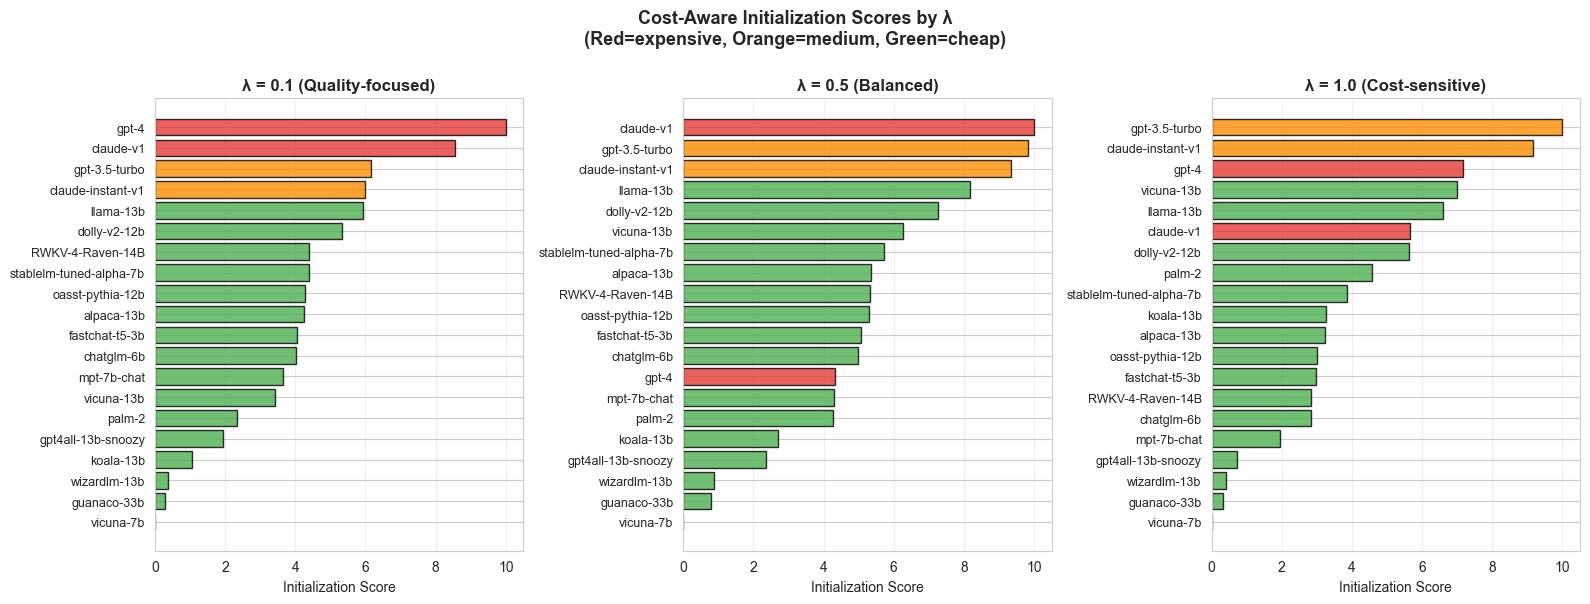

Visualization created: cost_aware_scores_by_lambda.png


In [108]:
# Visualize cost-aware scores
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for idx, lam in enumerate(lambda_values):
    ax = axes[idx]
    scores = cost_aware_scores[lam]
    
    # Sort by score
    sorted_models = sorted(scores.keys(), key=lambda m: scores[m], reverse=True)
    sorted_scores = [scores[m] for m in sorted_models]
    
    # Color by cost
    colors = []
    for m in sorted_models:
        cost = get_normalized_cost(m)
        if cost > 0.3: 
            colors.append('#E53935')  # Red: expensive
        elif cost > 0.05: 
            colors.append('#FB8C00')  # Orange: medium
        else: 
            colors.append('#4CAF50')  # Green: cheap
    
    # Plot
    ax.barh(range(len(sorted_models)), sorted_scores, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(sorted_models)))
    ax.set_yticklabels(sorted_models, fontsize=9)
    ax.set_xlabel('Initialization Score')
    
    label = 'Quality-focused' if lam == 0.1 else 'Balanced' if lam == 0.5 else 'Cost-sensitive'
    ax.set_title(f'λ = {lam} ({label})', fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Cost-Aware Initialization Scores by λ\n(Red=expensive, Orange=medium, Green=cheap)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('cost_aware_scores_by_lambda.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization created: cost_aware_scores_by_lambda.png")

In [109]:
# Save cost-aware initialization scores
print("\nSaving cost-aware initialization scores...\n")

cost_aware_output = {}
for lam in lambda_values:
    scores_json = {
        model: float(score) 
        for model, score in cost_aware_scores[lam].items()
    }
    cost_aware_output[f"lambda_{lam}"] = scores_json

output_path_cost_aware = 'data/dueling_initialization_scores_cost_aware.json'
with open(output_path_cost_aware, 'w') as f:
    json.dump(cost_aware_output, f, indent=2)

print(f"✓ Cost-aware scores saved to: {output_path_cost_aware}")

# Also save context weights from each model
print("\nSaving cost-aware context weights...\n")

weights_output = {}
for lam in lambda_values:
    weights = cost_aware_models[lam].get_context_aware_weights()
    weights_json = {
        model: weights[model].tolist()
        for model in model_names
    }
    weights_output[f"lambda_{lam}"] = weights_json

output_path_weights_aware = 'data/dueling_context_weights_cost_aware.json'
with open(output_path_weights_aware, 'w') as f:
    json.dump(weights_output, f, indent=2)

print(f"✓ Cost-aware context weights saved to: {output_path_weights_aware}")

# Save summary
summary_output = {
    'metadata': {
        'algorithm': 'Cost-Aware Dueling Bandit (Continuous Rewards)',
        'dataset': 'df_bandit.json',
        'timestamp': pd.Timestamp.now().isoformat(),
        'n_models': len(model_names),
        'n_features': len(semantic_features),
        'n_pairs': len(df_phase1),
        'lambda_values': lambda_values,
        'cost_aware': True,
        'feature_type': 'continuous',
        'features': semantic_features,
        'training_method': 'Margin-based on reward scores (quality - λ*cost)',
        'note': 'Cost as context feature allows learning context-specific cost sensitivity for each λ',
    },
    'models': {}
}

for lam in lambda_values:
    summary_output['models'][f'lambda_{lam}'] = cost_aware_models[lam].get_training_summary()

output_path_summary_aware = 'data/dueling_training_summary_cost_aware.json'
with open(output_path_summary_aware, 'w') as f:
    json.dump(summary_output, f, indent=2)

print(f"✓ Cost-aware summary saved to: {output_path_summary_aware}")

print("\n" + "="*70)
print("COST-AWARE DUELING BANDIT COMPLETE")
print("="*70)
print("\nGenerated files:")
print(f"  1. {output_path_cost_aware}")
print(f"     Initialization scores for each λ [0-10]")
print(f"  2. {output_path_weights_aware}")
print(f"     Context-aware weights for each λ")
print(f"  3. {output_path_summary_aware}")
print(f"     Training metadata")
print("\nContinuous feature setup:")
print(f"  ✓ Features: difficulty_norm [0,1], length_norm [0,1], cost_diff")
print(f"  ✓ 3 features per model × 3 lambda values = 9 weight sets total")
print(f"  ✓ Trained on continuous rewards (quality - λ*cost)")
print(f"  ✓ Separate initialization for each λ value")
print(f"  ✓ Cost as context feature enables context-aware cost handling")


Saving cost-aware initialization scores...

✓ Cost-aware scores saved to: data/dueling_initialization_scores_cost_aware.json

Saving cost-aware context weights...

✓ Cost-aware context weights saved to: data/dueling_context_weights_cost_aware.json
✓ Cost-aware summary saved to: data/dueling_training_summary_cost_aware.json

COST-AWARE DUELING BANDIT COMPLETE

Generated files:
  1. data/dueling_initialization_scores_cost_aware.json
     Initialization scores for each λ [0-10]
  2. data/dueling_context_weights_cost_aware.json
     Context-aware weights for each λ
  3. data/dueling_training_summary_cost_aware.json
     Training metadata

Continuous feature setup:
  ✓ Features: difficulty_norm [0,1], length_norm [0,1], cost_diff
  ✓ 3 features per model × 3 lambda values = 9 weight sets total
  ✓ Trained on continuous rewards (quality - λ*cost)
  ✓ Separate initialization for each λ value
  ✓ Cost as context feature enables context-aware cost handling
